# **Data Collection & Dataset Understanding**
**Decodelabs Internship | Week 2 | Task 1**

---
I downloaded the UCI Diabetes 130-US Hospitals dataset from the official source,
extracted it from its ZIP archive and loaded it into pandas.


In [1]:
import sys, os
# Add project root to Python path so we can import configs and src
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from configs.config import (
    RAW_FILE, IDS_MAP_FILE, INTERIM_FILE, PROCESSED_FILE,
    TRAIN_FILE, VAL_FILE, TEST_FILE,
    FIGURES_DIR, TABLES_DIR, PAPER_FIG_DIR, PAPER_TAB_DIR,
    RANDOM_SEED, TARGET_COL, PATIENT_ID_COL, MEDICATION_COLS,
    AGE_ORDER, icd9_to_category, COLORS, ensure_dirs
)
from src.plot_utils import set_plot_style, save_figure
ensure_dirs()
set_plot_style()
print("Project config loaded. Random seed:", RANDOM_SEED)

Project config loaded. Random seed: 42


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import zipfile
import io
import os

print(f"pandas version : {pd.__version__}")
print(f"numpy  version : {np.__version__}")

pandas version : 2.3.3
numpy  version : 2.4.6


## Downloading the dataset from UCI

I am downloading it only if the extracted CSV doesn't already exist. This avoids re-downloading on every notebook run.

In [ ]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip"

raw_dir = os.path.dirname(RAW_FILE)

if os.path.exists(RAW_FILE):
    print(f"Data already exists: {RAW_FILE}")
    print("Skipping download.")
else:
    print("Downloading dataset from UCI ML Repository...")
    print(f"URL: {DATA_URL}")
    
    response = requests.get(DATA_URL, timeout=120)
    
    if response.status_code == 200:
        print(f"Download complete. File size: {len(response.content)/1024/1024:.1f} MB")
        
        # Extract the ZIP in memory
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            print(f"ZIP contents: {z.namelist()}")
            z.extractall(raw_dir)
        
        print(f"Extracted to: {raw_dir}")
        print(f"Files in raw/: {os.listdir(raw_dir)}")
    else:
        print(f"Download failed. HTTP status: {response.status_code}")
        print("Please download manually from:")
        print(DATA_URL)
        print("And extract to:", raw_dir)

Data already exists: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\data\raw\diabetic_data.csv
Skipping download.


## Loading the main dataset

In [3]:
df_raw = pd.read_csv(RAW_FILE, low_memory=False)

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Shape: 101,766 rows × 50 columns
Memory usage: 220.2 MB


## First look

In [4]:
print("=== First 5 rows ===")
df_raw.head()

=== First 5 rows ===


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
# .info() gives the most important first-pass summary
print("=== DataFrame Info ===")
df_raw.info(verbose=True, show_counts=True)

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non

## Column inventory and data dictionary

I built a data dictionary that describes every column. For a 50-column dataset, this documentation is essential.

In [9]:
col_info = []

for col in df_raw.columns:
    n_unique = df_raw[col].nunique()
    n_missing = (df_raw[col] == "?").sum() if df_raw[col].dtype == object else df_raw[col].isnull().sum()
    sample_values = df_raw[col].dropna().unique()[:4]
    
    col_info.append({
        "Column": col,
        "Dtype": str(df_raw[col].dtype),
        "N_Unique": n_unique,
        "N_Missing_or_?": n_missing,
        "Sample Values": str(list(sample_values))[:60]
    })

col_df = pd.DataFrame(col_info)
print(f"Total columns: {len(col_df)}")
col_df

Total columns: 50


,Column,Dtype,N_Unique,N_Missing_or_?,Sample Values
0,encounter_id,int64,101766,0,"[np.int64(2278392), np.int64(149190), np.int64..."
1,patient_nbr,int64,71518,0,"[np.int64(8222157), np.int64(55629189), np.int..."
2,race,object,6,2273,"['Caucasian', 'AfricanAmerican', '?', 'Other']"
3,gender,object,3,0,"['Female', 'Male', 'Unknown/Invalid']"
4,age,object,10,0,"['[0-10)', '[10-20)', '[20-30)', '[30-40)']"
5,weight,object,10,98569,"['?', '[75-100)', '[50-75)', '[0-25)']"
6,admission_type_id,int64,8,0,"[np.int64(6), np.int64(1), np.int64(2), np.int..."
7,discharge_disposition_id,int64,26,0,"[np.int64(25), np.int64(1), np.int64(3), np.in..."
8,admission_source_id,int64,17,0,"[np.int64(1), np.int64(7), np.int64(2), np.int..."
9,time_in_hospital,int64,14,0,"[np.int64(1), np.int64(3), np.int64(2), np.int..."


## Understanding the '?' problem

The dataset uses '?' to represent missing values in object (string) columns. This is different from NaN, so pandas does NOT automatically recognise '?' as missing. I will handle this explicitly in the cleaning step (Notebook 02).

In [10]:
print("=== Columns with '?' values ===")
question_counts = {}
for col in df_raw.select_dtypes(include="object").columns:
    n = (df_raw[col] == "?").sum()
    if n > 0:
        question_counts[col] = n

for col, n in sorted(question_counts.items(), key=lambda x: -x[1]):
    pct = n / len(df_raw) * 100
    print(f"  {col:30s}: {n:6,} ({pct:.1f}%)")

print(f"\nTotal '?' values across all columns: {sum(question_counts.values()):,}")

=== Columns with '?' values ===
  weight                        : 98,569 (96.9%)
  medical_specialty             : 49,949 (49.1%)
  payer_code                    : 40,256 (39.6%)
  race                          :  2,273 (2.2%)
  diag_3                        :  1,423 (1.4%)
  diag_2                        :    358 (0.4%)
  diag_1                        :     21 (0.0%)

Total '?' values across all columns: 192,849


## Inspecting the target variable

The target is 'readmitted' with three values: `NO`, `>30`, `<30`

In [11]:
print("=== Target: readmitted ===")
target_counts = df_raw["readmitted"].value_counts()
target_pcts   = df_raw["readmitted"].value_counts(normalize=True) * 100

for val in target_counts.index:
    print(f"  {val:5s} : {target_counts[val]:7,} ({target_pcts[val]:5.1f}%)")

print()
print("Binary interpretation:")
early = (df_raw["readmitted"] == "<30").sum()
other = (df_raw["readmitted"] != "<30").sum()
print(f"  Early readmission (<30 days)  : {early:7,} ({early/len(df_raw)*100:.1f}%)")
print(f"  No early readmission (NO/>30) : {other:7,} ({other/len(df_raw)*100:.1f}%)")

=== Target: readmitted ===
  NO    :  54,864 ( 53.9%)
  >30   :  35,545 ( 34.9%)
  <30   :  11,357 ( 11.2%)

Binary interpretation:
  Early readmission (<30 days)  :  11,357 (11.2%)
  No early readmission (NO/>30) :  90,409 (88.8%)


**Note:** ~11% early readmission rate. This is a CLASS IMBALANCE problem, I will need to handle it carefully during modelling (Notebook 07-08).

## Checking unique patient count vs row count

The dataset has multiple encounters per patient. This means the same patient can appear in both training and test sets if I split randomly by row, that will be a form of data leakage.

In [12]:
n_rows     = len(df_raw)
n_patients = df_raw["patient_nbr"].nunique()

print(f"Total encounters (rows)       : {n_rows:,}")
print(f"Unique patients               : {n_patients:,}")
print(f"Average encounters per patient: {n_rows/n_patients:.2f}")
print()

# How many patients have multiple encounters?
encounter_counts = df_raw.groupby("patient_nbr").size()
multi = (encounter_counts > 1).sum()
print(f"Patients with > 1 encounter   : {multi:,} ({multi/n_patients*100:.1f}%)")
print(f"Patients with 1  encounter    : {(encounter_counts == 1).sum():,}")

Total encounters (rows)       : 101,766
Unique patients               : 71,518
Average encounters per patient: 1.42

Patients with > 1 encounter   : 16,773 (23.5%)
Patients with 1  encounter    : 54,745


I must split by patient, not by row. I will address this in Notebook 06 (Leakage & Splits).

## Inspecting age distribution

=== Age Distribution ===
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\01_age_distribution.png


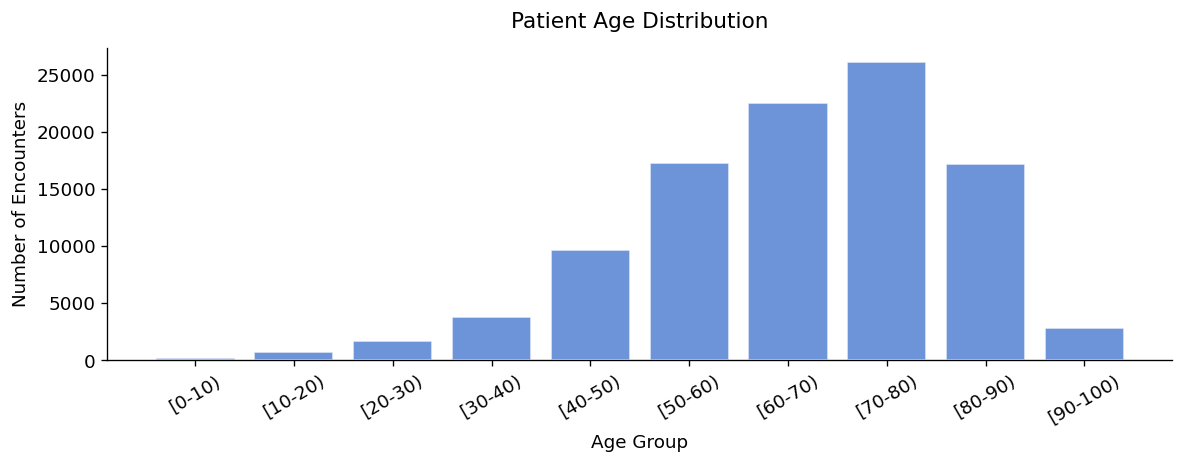

In [13]:
print("=== Age Distribution ===")
age_counts = df_raw["age"].value_counts().sort_index()
print(age_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(age_counts.index, age_counts.values, color=COLORS["no_readmit"],
       alpha=0.8, edgecolor="white")
ax.set_title("Patient Age Distribution", pad=12)
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Encounters")
plt.xticks(rotation=30)
plt.tight_layout()
save_figure(fig, "01_age_distribution.png", FIGURES_DIR)
plt.show()

## Inspecting diagnosis columns

The dataset has three ICD-9 diagnosis code columns: diag_1, diag_2, diag_3. These contain raw ICD-9 codes like '250', '428', 'E11.9', etc. I inspect how many unique codes there are and what the most common ones look like.

In [14]:
for diag_col in ["diag_1", "diag_2", "diag_3"]:
    n_unique = df_raw[diag_col].nunique()
    top5 = df_raw[diag_col].value_counts().head(5)
    n_q  = (df_raw[diag_col] == "?").sum()
    print(f"=== {diag_col} ===")
    print(f"  Unique values: {n_unique:,}  |  '?' count: {n_q:,}")
    print(f"  Top 5 codes:")
    for code, cnt in top5.items():
        print(f"    {code:8s}: {cnt:,}")

=== diag_1 ===
  Unique values: 717  |  '?' count: 21
  Top 5 codes:
    428     : 6,862
    414     : 6,581
    786     : 4,016
    410     : 3,614
    486     : 3,508
=== diag_2 ===
  Unique values: 749  |  '?' count: 358
  Top 5 codes:
    276     : 6,752
    428     : 6,662
    250     : 6,071
    427     : 5,036
    401     : 3,736
=== diag_3 ===
  Unique values: 790  |  '?' count: 1,423
  Top 5 codes:
    250     : 11,555
    401     : 8,289
    276     : 5,175
    428     : 4,577
    427     : 3,955


ICD-9 codes will be grouped into disease categories in Notebook 03.

## Loading and inspecting the ID mapping file

In [15]:
ids_df = pd.read_csv(IDS_MAP_FILE)
print(f"IDs mapping file: {ids_df.shape[0]} rows × {ids_df.shape[1]} columns")
print()
print(ids_df.head(20).to_string())

IDs mapping file: 67 rows × 2 columns

           admission_type_id                                                           description
0                          1                                                             Emergency
1                          2                                                                Urgent
2                          3                                                              Elective
3                          4                                                               Newborn
4                          5                                                         Not Available
5                          6                                                                   NaN
6                          7                                                         Trauma Center
7                          8                                                            Not Mapped
8                        NaN                                          

## Summary of Notebook 01

I loaded the **UCI Diabetes 130-US Hospitals** dataset:
- **101,766 encounters**, **50 columns**, **~71,518 unique patients**
- Target: `readmitted` — ~11% early readmission rate (class imbalance)
- Missing values encoded as **`?`** in string columns; need explicit handling
- Key columns with heavy missingness: `weight` (~97%), `payer_code` (~40%), `medical_specialty` (~49%)
- ICD-9 diagnosis codes need grouping (thousands of unique values)
- **Patient-aware splitting is essential** — same patient can appear multiple times

**Next step:** Notebook 02 — Data Cleaning & Preprocessing


I was surprised when the columns `A1Cresult` and `max_glu_serum` recorded zero missingness in this notebook, but suddenly recorded high missingness in the second notebook during data cleaning. Apparently the two checks measured missingness differently: the inventory counted only the string `?` for object columns, but as the `value_counts(dropna=False)` output shows, these columns already held genuine NaN (84,748 and 96,420) in the raw file, not `?`. So they were never truly complete. 

In [16]:
df_raw["A1Cresult"].value_counts(dropna=False)

A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

In [17]:
df_raw["max_glu_serum"].value_counts(dropna=False)


max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64